In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("AI_Job_Layoffs_Cleaned.csv")

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
print("Total Layoff Events :", len(df))

Total Layoff Events : 1350


In [5]:
print("Total Employees Laid Off :", df['headcount_cut'].sum())

Total Employees Laid Off : 3317282


In [6]:
print("Average Employees Laid Off :", round(df['headcount_cut'].mean(),2))

Average Employees Laid Off : 2457.25


In [7]:
print("Maximum Employees Laid Off :", df['headcount_cut'].max())

Maximum Employees Laid Off : 52864


In [8]:
print("Minimum Employees Laid Off :", df['headcount_cut'].min())

Minimum Employees Laid Off : 5


In [9]:
yearly = df.groupby('year')['headcount_cut'].sum().reset_index()

yearly

,year,headcount_cut
0,2023.0,217998
1,2024.0,470650
2,2025.0,2102439
3,2026.0,526195


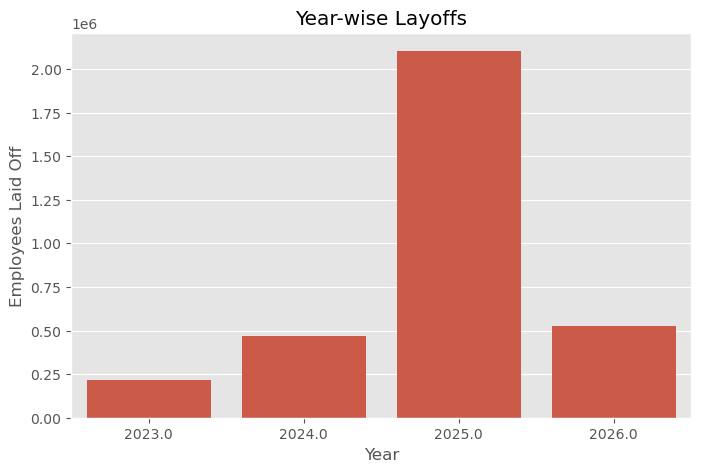

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(data=yearly,
            x='year',
            y='headcount_cut')

plt.title("Year-wise Layoffs")
plt.xlabel("Year")
plt.ylabel("Employees Laid Off")

plt.show()

In [11]:
monthly = df.groupby('month')['headcount_cut'].sum().reset_index()

monthly

,month,headcount_cut
0,April,140444
1,August,184521
2,December,103732
3,February,83377
4,January,110245
5,July,1865472
6,June,169753
7,March,90709
8,May,103614
9,November,204844


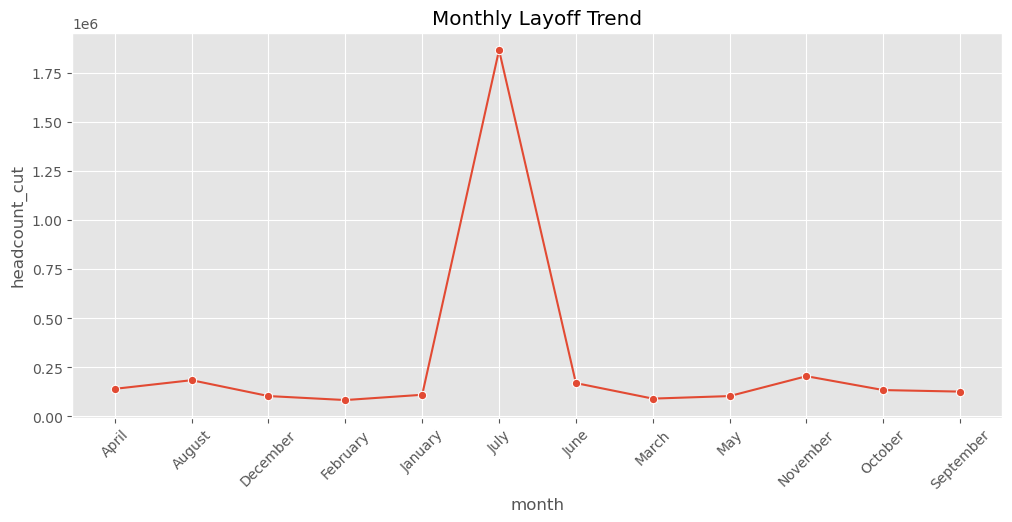

In [12]:
plt.figure(figsize=(12,5))

sns.lineplot(data=monthly,
             x='month',
             y='headcount_cut',
             marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Layoff Trend")

plt.show()

In [13]:
industry = df.groupby('industry')['headcount_cut'].sum().sort_values(ascending=False)

industry

industry
Technology/Software                 763538
Retail/E-commerce                   420598
Transportation/Logistics            367601
Finance/Banking                     313411
Consumer Internet                   272639
Pharma/Chemicals                    254501
Telecom                             237713
Media/Content                       223773
Healthcare                          160967
Energy                              125630
Consulting/Professional Services    109348
Manufacturing                        67563
Name: headcount_cut, dtype: int64

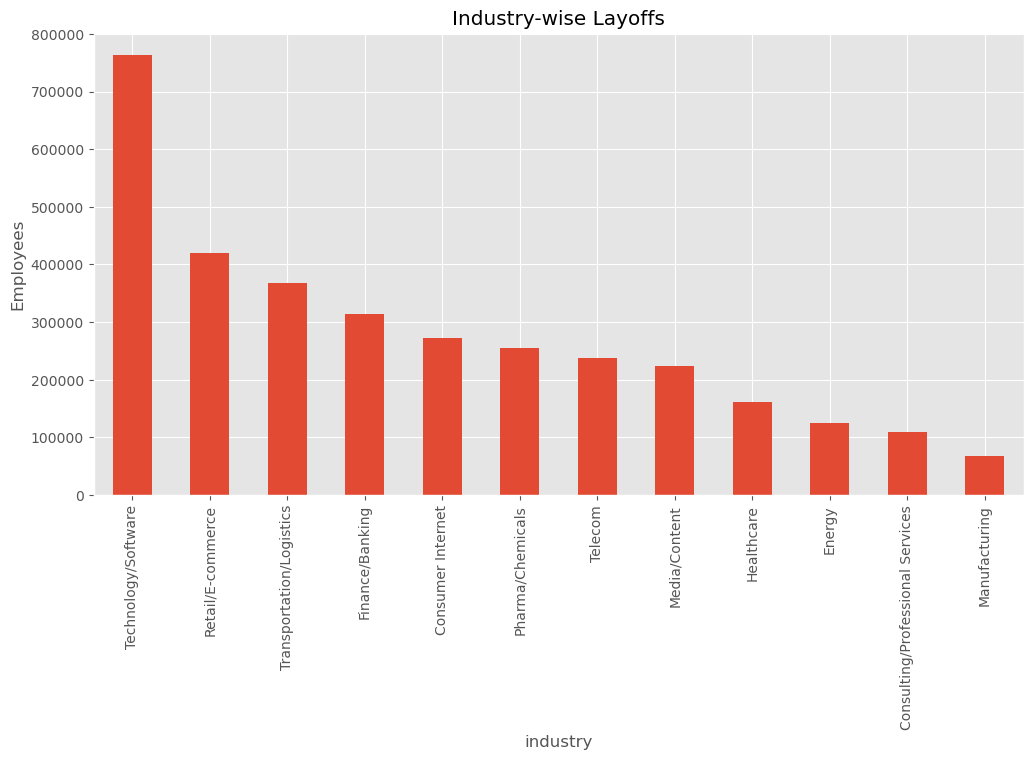

In [14]:
plt.figure(figsize=(12,6))

industry.plot(kind='bar')

plt.title("Industry-wise Layoffs")

plt.ylabel("Employees")

plt.show()

In [15]:
top_company = df.groupby('company_name')['headcount_cut'].sum().nlargest(10)

top_company

company_name
IonixTechnologies    126739
AstraSystems         110843
CorPartners           96993
JunoSolutions         93502
OnyxPartners          91068
VorGlobal             80132
JunoLabs              77029
MeridianDynamics      76470
SilverHoldings        76262
QuantSolutions        70701
Name: headcount_cut, dtype: int64

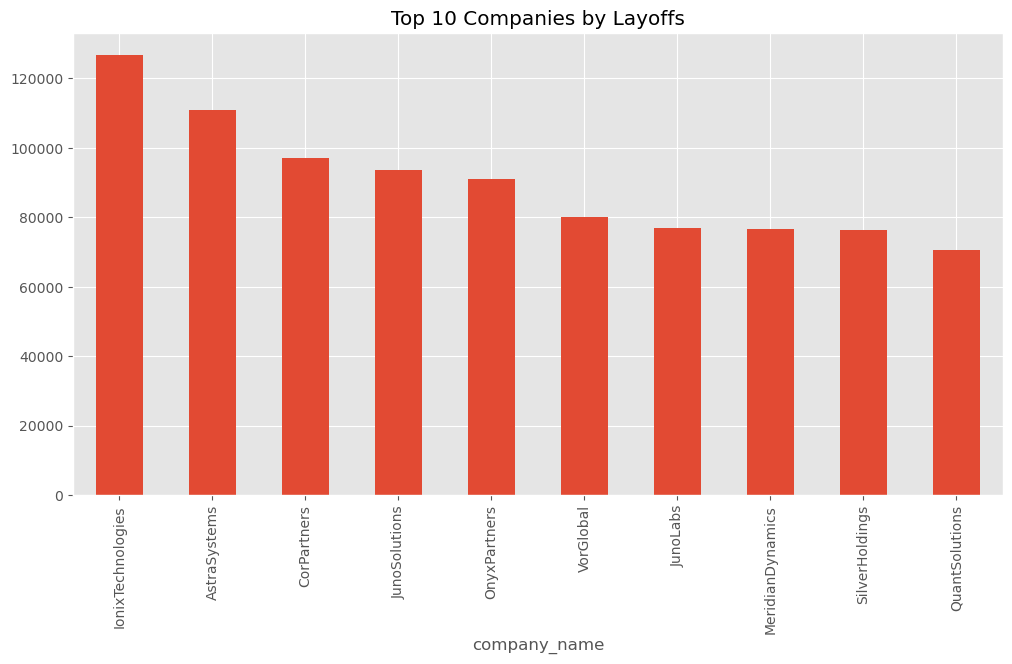

In [16]:
plt.figure(figsize=(12,6))

top_company.plot(kind='bar')

plt.title("Top 10 Companies by Layoffs")

plt.show()

In [17]:
country = df.groupby('country')['headcount_cut'].sum().sort_values(ascending=False)

country

country
United States     747734
Mexico            648373
Canada            644930
Argentina         152492
Germany           136438
France            129260
Brazil            128708
Japan             115026
India             110412
Netherlands       101339
United Kingdom     85019
Australia          68955
Chile              55856
China              47943
Singapore          44126
Saudi Arabia       42958
Ireland            34102
South Africa       20054
UAE                 3557
Name: headcount_cut, dtype: int64

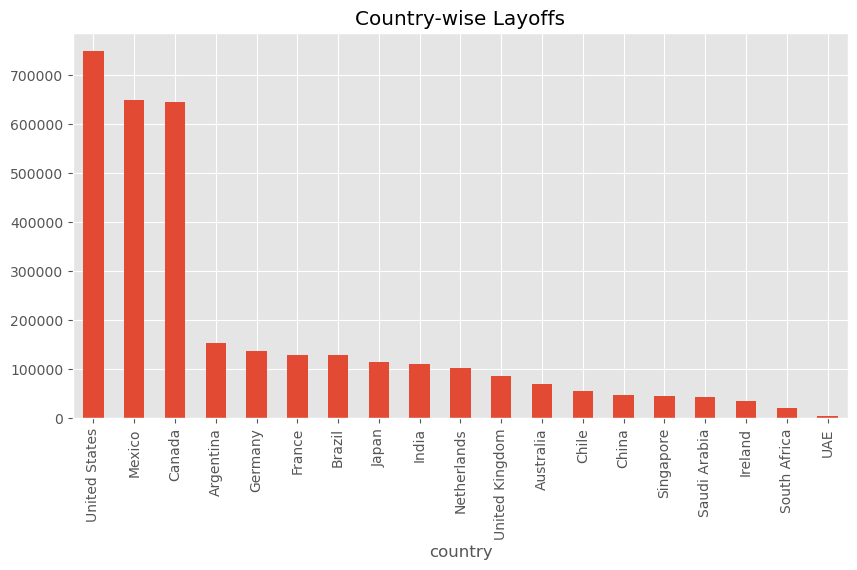

In [18]:
plt.figure(figsize=(10,5))

country.plot(kind='bar')

plt.title("Country-wise Layoffs")

plt.show()

In [19]:
df['ai_cited_as_reason'].value_counts()

ai_cited_as_reason
No     750
Yes    600
Name: count, dtype: int64

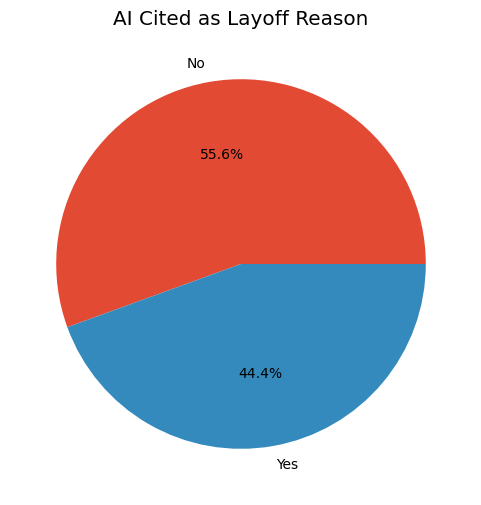

In [20]:
plt.figure(figsize=(6,6))

df['ai_cited_as_reason'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("AI Cited as Layoff Reason")

plt.show()

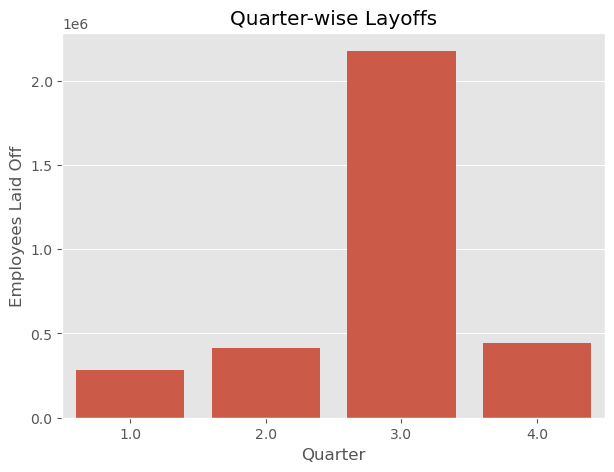

In [21]:
quarterly = df.groupby('quarter')['headcount_cut'].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=quarterly, x='quarter', y='headcount_cut')

plt.title("Quarter-wise Layoffs")
plt.xlabel("Quarter")
plt.ylabel("Employees Laid Off")
plt.show()

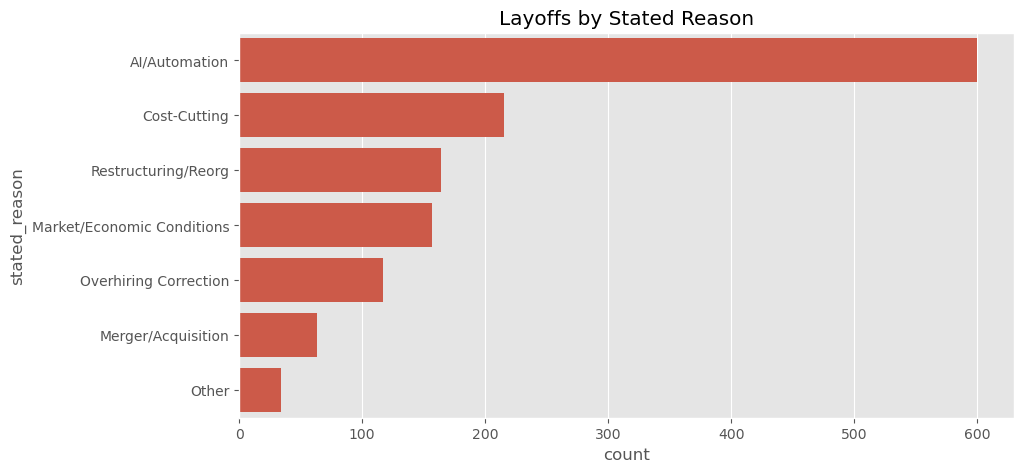

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='stated_reason',
    order=df['stated_reason'].value_counts().index
)

plt.title("Layoffs by Stated Reason")
plt.show()

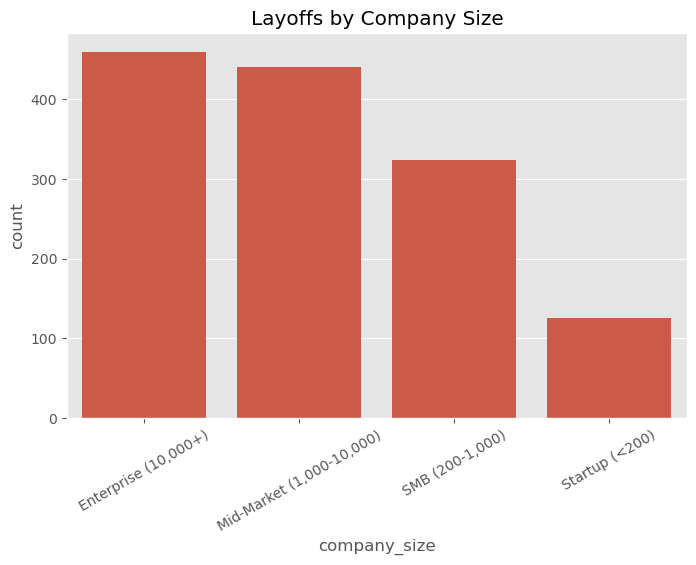

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='company_size',
    order=df['company_size'].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Layoffs by Company Size")

plt.show()

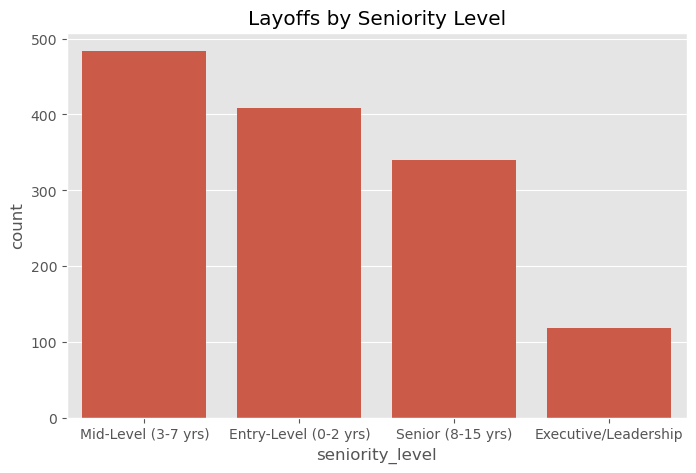

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='seniority_level',
    order=df['seniority_level'].value_counts().index
)

plt.title("Layoffs by Seniority Level")

plt.show()

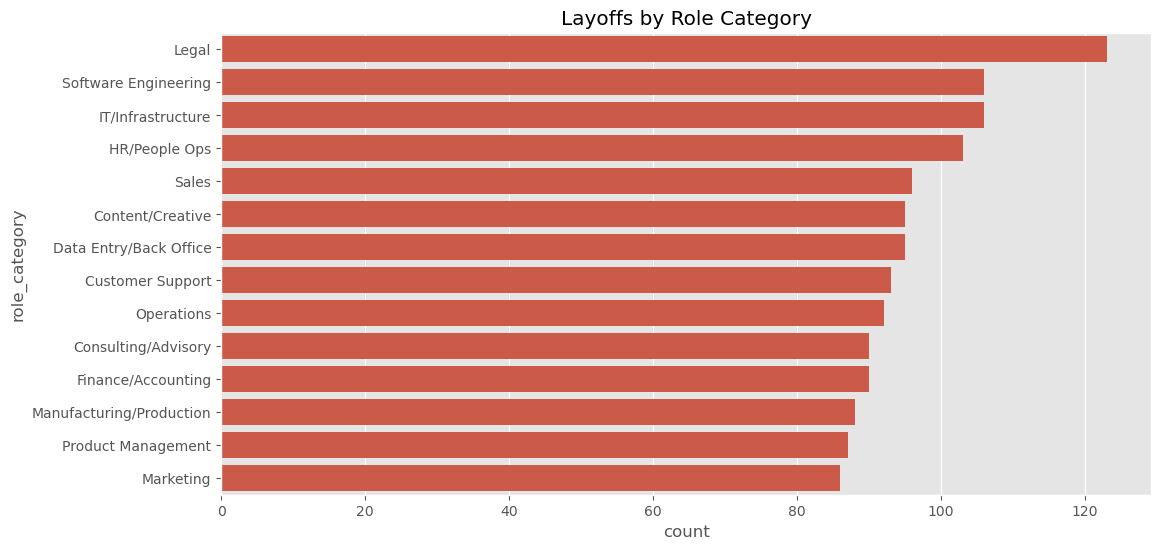

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='role_category',
    order=df['role_category'].value_counts().index
)

plt.title("Layoffs by Role Category")

plt.show()

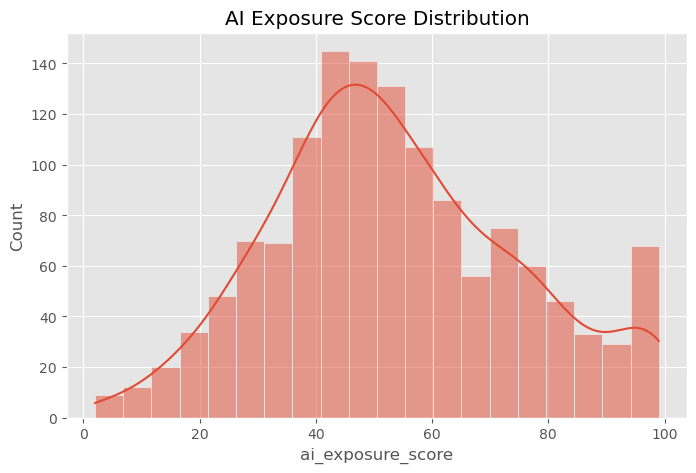

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['ai_exposure_score'], bins=20, kde=True)

plt.title("AI Exposure Score Distribution")

plt.show()

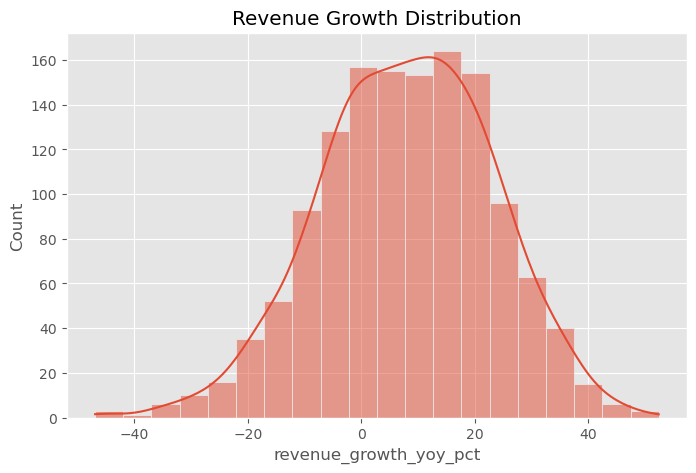

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['revenue_growth_yoy_pct'], bins=20, kde=True)

plt.title("Revenue Growth Distribution")

plt.show()

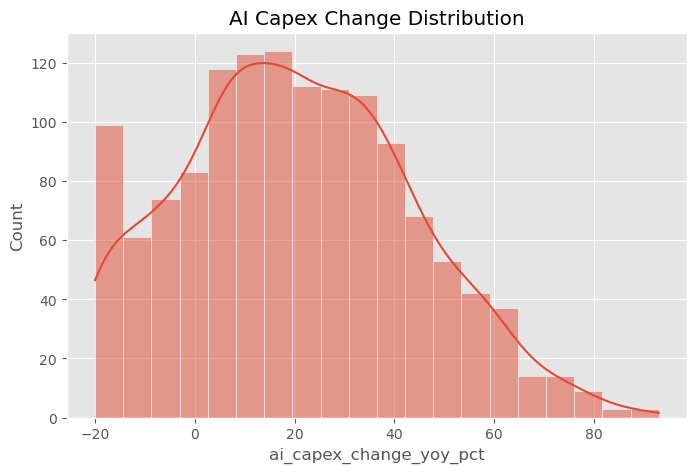

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['ai_capex_change_yoy_pct'], bins=20, kde=True)

plt.title("AI Capex Change Distribution")

plt.show()

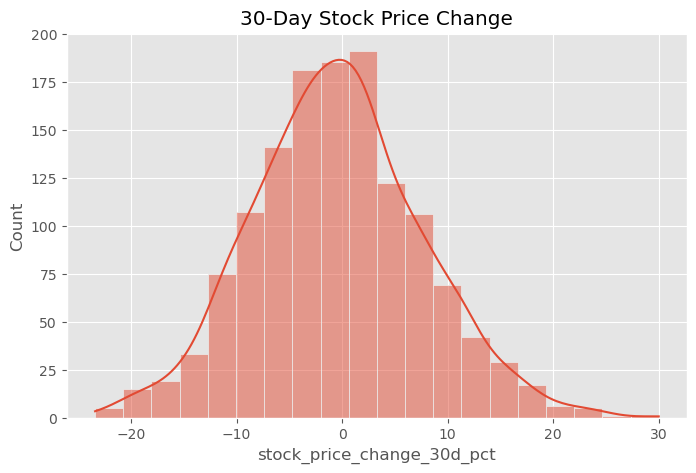

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['stock_price_change_30d_pct'], bins=20, kde=True)

plt.title("30-Day Stock Price Change")

plt.show()

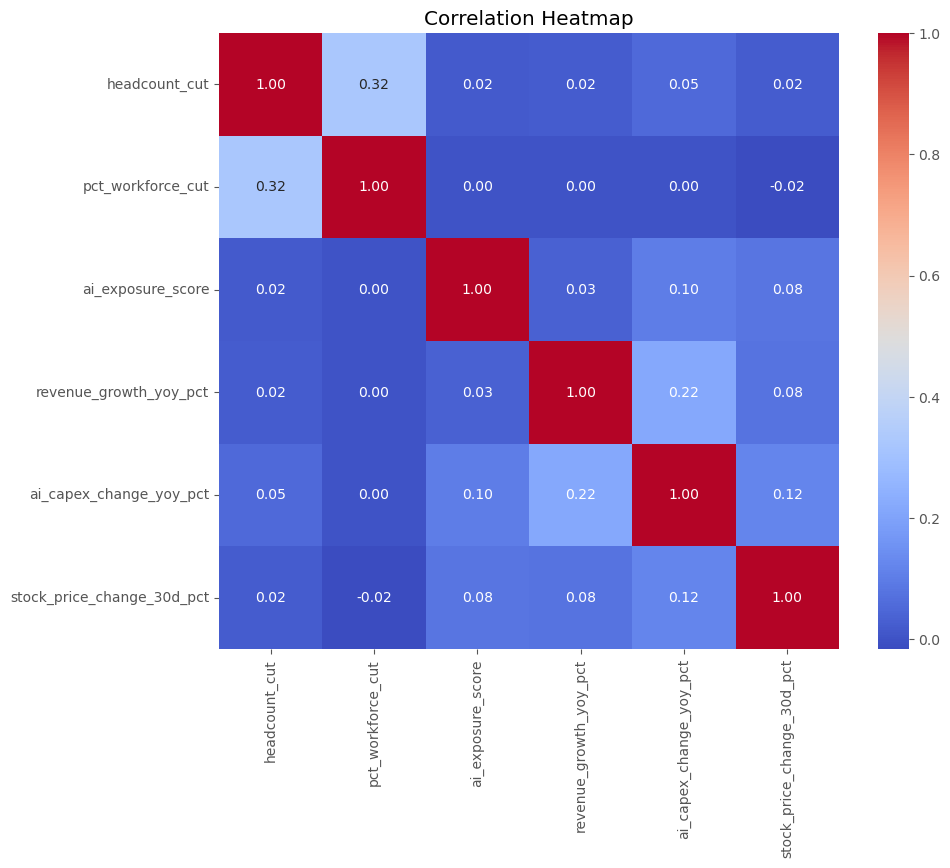

In [30]:
plt.figure(figsize=(10,8))

numerical_columns = [
    'headcount_cut',
    'pct_workforce_cut',
    'ai_exposure_score',
    'revenue_growth_yoy_pct',
    'ai_capex_change_yoy_pct',
    'stock_price_change_30d_pct'
]

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()